# Análisis Exploratorio de Datos

**Caso de Estudio:** Analítica de Clientes — Predicción de Abandono  
**Asignatura:** SCY1101 — Programación para la Ciencia de Datos  
**Evaluación Parcial N°2**

---

## Descripción

Este notebook realiza el análisis exploratorio del dataset de clientes de una empresa
de servicios digitales por suscripción. El objetivo de negocio es anticipar el
comportamiento de abandono para diseñar acciones preventivas.

Mantiene el uso de pipeline como buena práctica de la industria.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (>=3.7.1)
- numpy (>=2.0.0)
- seaborn (>=0.12.0)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [44]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use('bmh')

from sklearn.preprocessing import OneHotEncoder

In [2]:
data = pd.read_csv('../data/dataset_clientes.csv')
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


> Para la descripción detallada de los datos, por favor revisa el documento [`Caso_de_estudio.pdf`](../docs/Caso_de_estudio.pdf).

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

# Entendimiento de los datos

## Distribución de la variable objetivo (abandono)

La variable objetivo es binaria.
Esto determina que el problema principal es de clasificación, no de regresión.


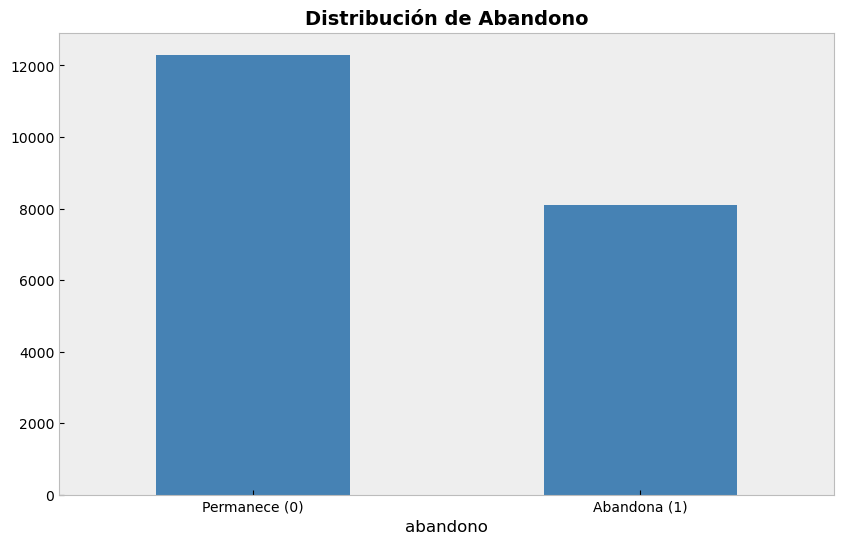

In [14]:
ax = data['abandono'].value_counts().sort_index().plot(
    kind='bar', 
    figsize=(10, 6), 
    color='steelblue',
    width=0.5,
    grid = False
)
plt.title('Distribución de Abandono', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Permanece (0)', 'Abandona (1)'], rotation=0)
plt.show()

## Detección de inconsistencias

In [16]:
# Detectar valores que no tienen sentido de negocio
inconsistentes = data[
    (data['deuda_total'] < 0) |
    (data['ingreso_mensual'] < 0) |
    (data['edad'] < 18) | (data['edad'] > 100) |
    (data['antiguedad_meses'] < 0)
]
inconsistentes[['edad','ingreso_mensual',
                          'deuda_total','antiguedad_meses']].head(10)

,edad,ingreso_mensual,deuda_total,antiguedad_meses
45,54,5.473621e+05,-8694.468176,22
70,61,7.716767e+05,-140806.057898,15
183,51,1.302779e+06,-348532.147302,22
333,23,1.164257e+06,-45067.673765,32
386,52,2.314476e+05,-486854.930914,98
436,59,8.502537e+05,-57991.545384,25
625,60,9.012112e+05,-30196.798683,47
727,20,8.008237e+05,-51381.443872,15
741,52,8.260922e+05,-188756.783598,35
810,36,1.018660e+06,-161457.353388,110


In [17]:
print('Deuda total negativa    :', (data['deuda_total'] < 0).sum())
print('Ingreso mensual negativo:', (data['ingreso_mensual'] < 0).sum())

Deuda total negativa    : 143
Ingreso mensual negativo: 11


## Detección de nulos

In [24]:
nulos = data.isnull().sum()
nulos_pct = (nulos / len(data) * 100).round(2)

resumen = pd.DataFrame({'Nulos': nulos}).query('Nulos > 0').sort_values('Nulos')

resumen

,Nulos
ingreso_mensual,1021
score_crediticio,1021
gasto_mensual,1025


## Detección de valores atípicos

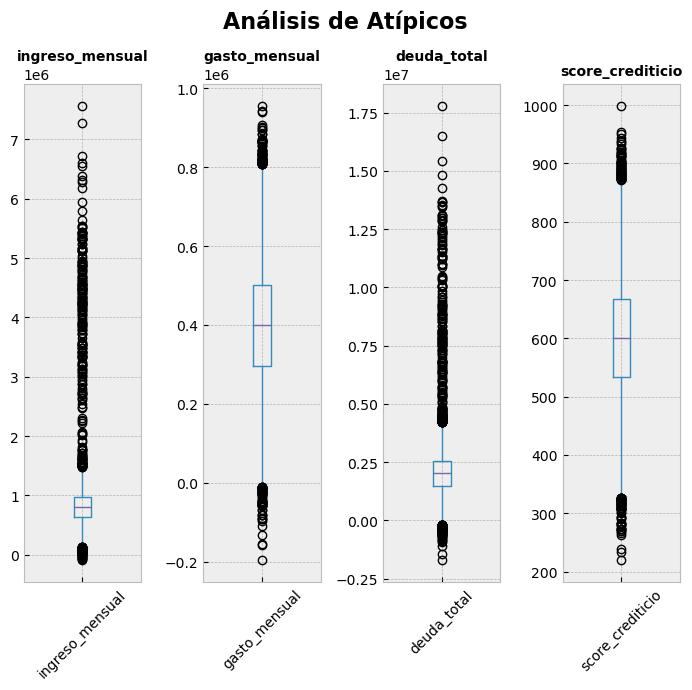

In [26]:
revision_atipicos = [
    'ingreso_mensual', 'gasto_mensual', 'deuda_total',
    'score_crediticio'
]

fig, axes = plt.subplots(1, 4, figsize=(24, 12))
axes = axes.flatten()

for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', figsize=(7, 7), ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelrotation=45)

plt.suptitle('Análisis de Atípicos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/01_atipicos.png', dpi=150, bbox_inches='tight')
plt.show()


## Detección de duplicados

In [27]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(400)

In [30]:
# Duplicados por id_cliente
dup_id = data.duplicated(subset=['id_cliente']).sum()
print(f'IDs de cliente duplicados: {dup_id}')
data[data.duplicated(subset=['id_cliente'], keep=False)]

IDs de cliente duplicados: 400


,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
177,178,2022-02-16,58,Otro,Centro,Soltero,5.747343e+05,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
215,216,2021-05-23,77,Femenino,Centro,Divorciado,6.962513e+05,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
326,327,2019-07-15,43,Femenino,Sur,Soltero,6.110187e+05,238932.156632,8.764364e+05,618.183493,...,303,Medio,Basico,3,0,App,Lunes,11,6291,0
353,354,2020-06-12,53,Otro,Sur,Divorciado,2.275127e+05,602873.962513,2.863745e+06,473.807220,...,180,Bajo,Premium,4,1,Web,Domingo,9,5028,1
415,416,2023-06-18,52,Otro,Sur,Soltero,7.190312e+05,566826.800985,2.735518e+06,586.009635,...,107,Bajo,Premium,5,0,Web,Martes,7,1813,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925,2021-08-09,47,Femenino,Centro,Divorciado,4.818457e+05,523321.283921,1.750852e+06,715.276140,...,39,Alto,Basico,1,0,Web,Viernes,4,5831,0
20396,1627,2021-10-26,18,Masculino,Sur,Divorciado,1.062000e+06,692112.449676,1.865442e+06,662.855074,...,319,Bajo,Premium,3,0,Web,Domingo,17,2925,0
20397,13007,2022-10-05,76,Femenino,Norte,Soltero,1.595617e+06,568544.699045,1.862204e+06,640.595219,...,325,Medio,Estandar,4,0,App,Viernes,16,1660,0
20398,17724,2020-01-10,23,Otro,Sur,Casado,8.056724e+05,348930.779211,2.032151e+06,466.372014,...,81,Bajo,Premium,2,0,Tienda,Lunes,14,4561,1


## Correlación con variables numéricas

In [34]:
# Calcula la matriz de correlaciones
cols_excluir = ['id_cliente', 'codigo_postal', 'hora_registro']
correlaciones = data.drop(columns=cols_excluir, errors='ignore').corr(numeric_only=True)

# Ver correlación con la variable objetivo
corr_abandono = correlaciones['abandono'].drop('abandono').sort_values(ascending=False)
corr_abandono

ultima_compra_dias       0.212881
deuda_total              0.027894
edad                     0.006120
ingreso_mensual          0.002454
tiene_tarjeta_credito   -0.000523
num_productos           -0.002652
antiguedad_meses        -0.005942
gasto_mensual           -0.008417
score_crediticio        -0.028777
frecuencia_compra       -0.044331
Name: abandono, dtype: float64

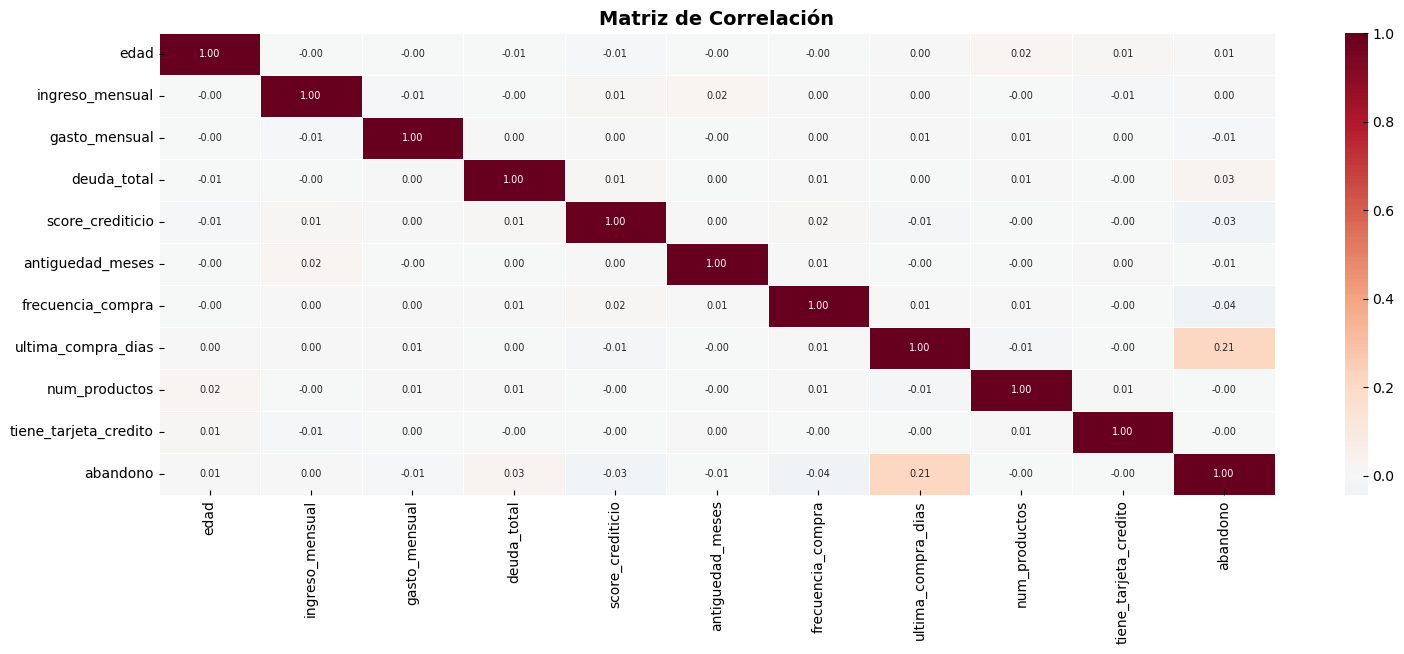

In [45]:
fig, ax = plt.subplots(figsize=(18, 6))

sb.heatmap(correlaciones, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
ax.grid(False)

plt.savefig('../results/plots/01_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()


## Correlación de variables categóricas con abandono

In [48]:
cats = ['genero', 'region', 'estado_civil', 'uso_app', 'tipo_plan', 'canal_registro']

encoder = OneHotEncoder(sparse_output=False)
cats_encoded = encoder.fit_transform(data[cats].fillna('Desconocido'))
data_ohe = pd.DataFrame(cats_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data.reset_index(drop=True), data_ohe], axis=1)
corr_cat = data_corr.corr(numeric_only=True)['abandono'][data_ohe.columns]

print('Correlación variables categóricas con abandono:')
display(corr_cat.sort_values(ascending=False))

Correlación variables categóricas con abandono:


uso_app_Bajo               0.188483
tipo_plan_Basico           0.092995
region_Sur                 0.010178
canal_registro_Tienda      0.009399
genero_Otro                0.005803
region_Centro              0.004641
estado_civil_Divorciado    0.004244
canal_registro_App        -0.000134
estado_civil_Soltero      -0.000742
genero_Masculino          -0.001880
estado_civil_Casado       -0.003492
genero_Femenino           -0.003982
canal_registro_Web        -0.009277
region_Norte              -0.014820
tipo_plan_Estandar        -0.042450
tipo_plan_Premium         -0.049823
uso_app_Alto              -0.093460
uso_app_Medio             -0.095918
Name: abandono, dtype: float64

## Análisis de variables categóricas por tasa de abandono

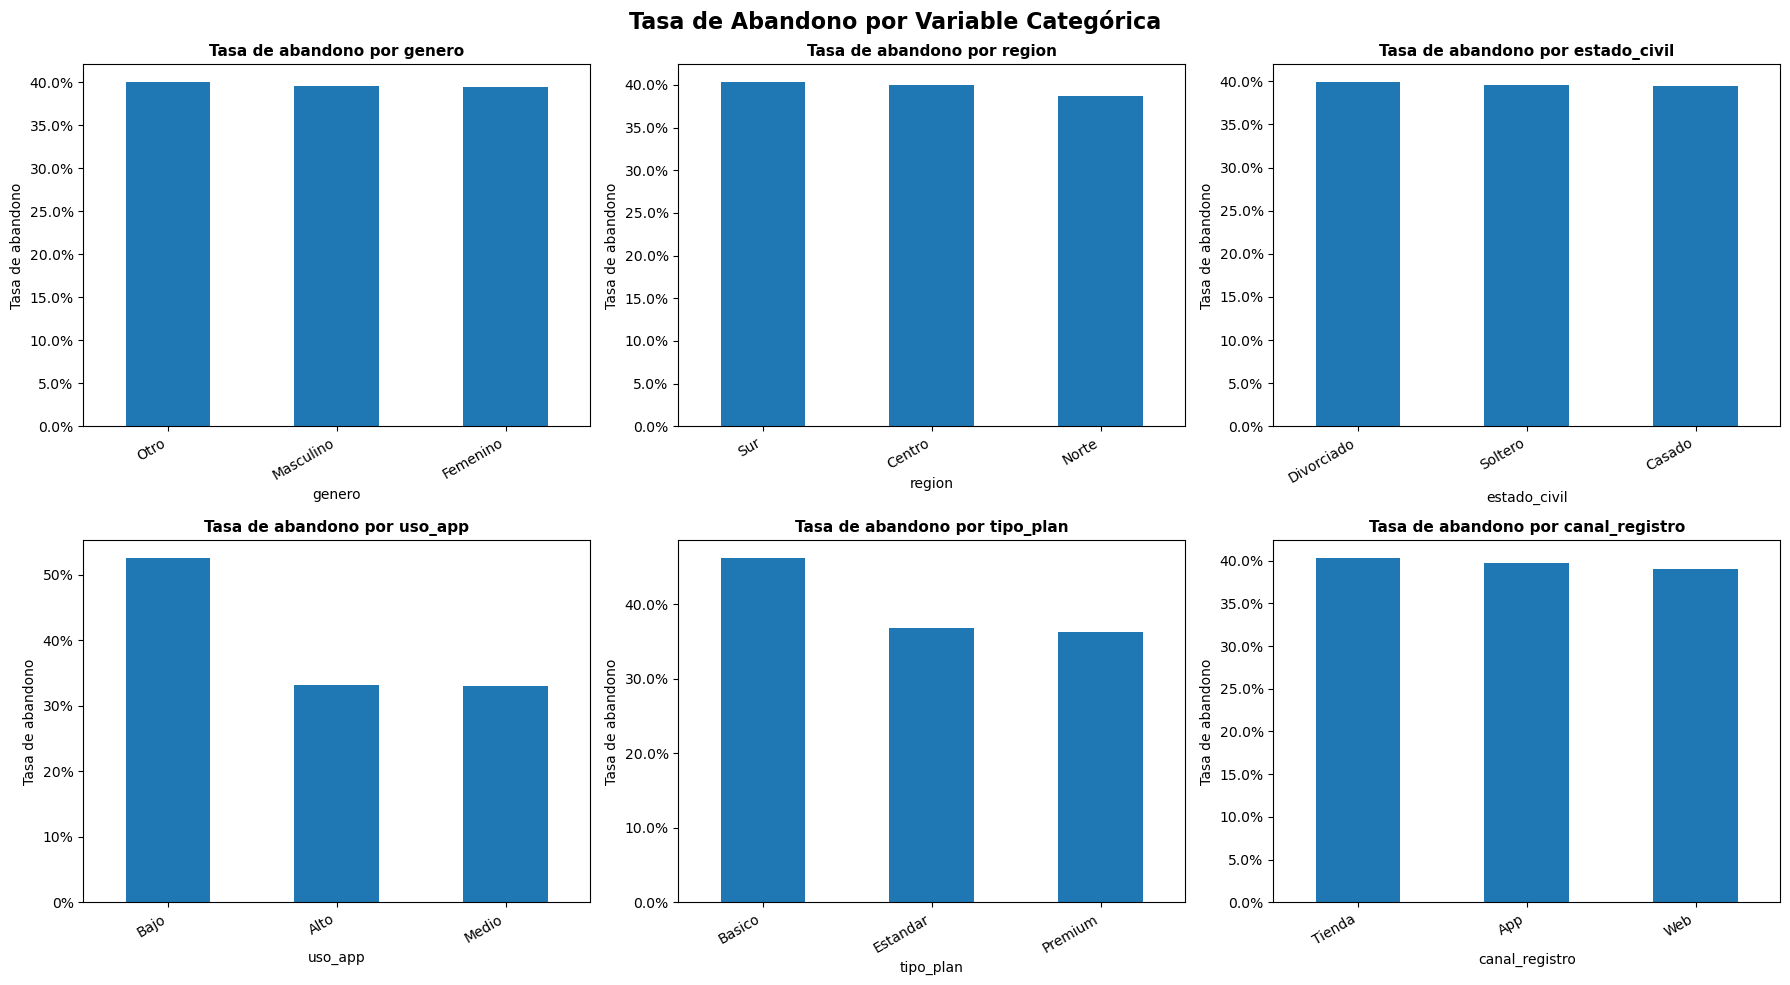

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cats):
    tasa = data.groupby(col)['abandono'].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Tasa de abandono por {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de abandono')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Tasa de Abandono por Variable Categórica', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/01_categoricas_abandono.png', dpi=150, bbox_inches='tight')
plt.show()


## Distribución de score_crediticio

Además del problema de clasificación (abandono), el dataset contiene variables
continuas como score_crediticio que pueden modelarse con regresión lineal y arboles de decisión.
Esto se explora en el notebook [02_supervised_modeling.ipynb](./02_supervised_modeling.ipynb).


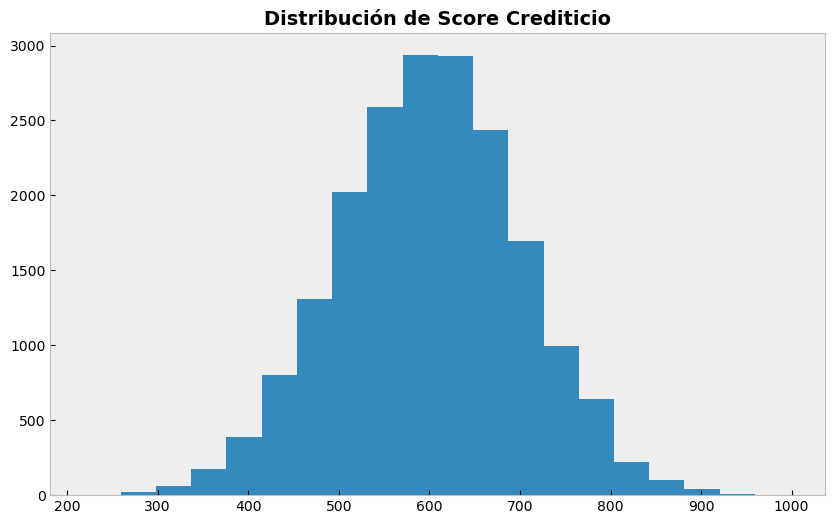

In [49]:
data['score_crediticio'].hist(bins=20, figsize=(10, 6), grid=False)
plt.title('Distribución de Score Crediticio', fontsize=14, fontweight='bold')
plt.show()

In [50]:
data['score_crediticio'].describe().round(2)

count    19379.00
mean       600.44
std        100.41
min        220.52
25%        532.87
50%        600.96
75%        668.25
max        998.29
Name: score_crediticio, dtype: float64